#Bibliotecas

In [1]:
import pandas as pd
import requests

#📌 Extracción

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [4]:
df.iloc[0]

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


In [5]:
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

 #### ✅ Explorar las columnas del dataset y verificar sus tipos de datos.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [7]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [8]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [9]:
df.shape

(7267, 21)

#### ✅ Consultar el diccionario para comprender mejor el significado de las variables.

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

#### ✅ Identificar las columnas más relevantes para el análisis de evasión.

In [10]:
customer_cols = [c for c in df.columns if c.startswith("customer.")]
phone_cols    = [c for c in df.columns if c.startswith("phone.")]
internet_cols = [c for c in df.columns if c.startswith("internet.")]
account_cols  = [c for c in df.columns if c.startswith("account.")]

print("Target:", "Churn")
print("ID:", "customerID")

print("\nCustomer (demografía/tenure):", customer_cols)
print("\nPhone (telefonía):", phone_cols)
print("\nInternet (servicios internet):", internet_cols)
print("\nAccount (contrato/pago/cargos):", account_cols)

Target: Churn
ID: customerID

Customer (demografía/tenure): ['customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure']

Phone (telefonía): ['phone.PhoneService', 'phone.MultipleLines']

Internet (servicios internet): ['internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies']

Account (contrato/pago/cargos): ['account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [11]:
#Verificar duplicados
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


In [12]:
#Verificar nulos
print("\nNulos por columna (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Nulos por columna (top 10):
customerID                  0
Churn                       0
customer.gender             0
customer.SeniorCitizen      0
customer.Partner            0
customer.Dependents         0
customer.tenure             0
phone.PhoneService          0
phone.MultipleLines         0
internet.InternetService    0
dtype: int64


In [13]:
#Verificar inconsistencias (Valores unicos)
for col in df.columns:
    n = df[col].nunique()
    print(f"Columna: {col} | únicos: {n}")

    if n <= 15:  # más controlado que 50
        print(df[col].unique())
        print("-" * 40)

Columna: customerID | únicos: 7267
Columna: Churn | únicos: 3
['No' 'Yes' '']
----------------------------------------
Columna: customer.gender | únicos: 2
['Female' 'Male']
----------------------------------------
Columna: customer.SeniorCitizen | únicos: 2
[0 1]
----------------------------------------
Columna: customer.Partner | únicos: 2
['Yes' 'No']
----------------------------------------
Columna: customer.Dependents | únicos: 2
['Yes' 'No']
----------------------------------------
Columna: customer.tenure | únicos: 73
Columna: phone.PhoneService | únicos: 2
['Yes' 'No']
----------------------------------------
Columna: phone.MultipleLines | únicos: 3
['No' 'Yes' 'No phone service']
----------------------------------------
Columna: internet.InternetService | únicos: 3
['DSL' 'Fiber optic' 'No']
----------------------------------------
Columna: internet.OnlineSecurity | únicos: 3
['No' 'Yes' 'No internet service']
----------------------------------------
Columna: internet.OnlineBa

In [14]:
#Valores vacios o en blanco
vacios = df.apply(lambda x: x.astype(str).str.strip().eq('').sum())
print("Vacíos (strings) por columna (top 10):")
print(vacios.sort_values(ascending=False).head(10))

Vacíos (strings) por columna (top 10):
Churn                       224
account.Charges.Total        11
customerID                    0
customer.SeniorCitizen        0
customer.gender               0
customer.Partner              0
customer.Dependents           0
phone.PhoneService            0
customer.tenure               0
internet.InternetService      0
dtype: int64


#### Inicia la transformación

In [15]:
#Limpiar churn (Estoy quitando espacios)
df["Churn"] = df["Churn"].astype(str).str.strip()

In [16]:
#Limpiar filas invalidas
df = df[df["Churn"] != ""]

In [17]:
#Eliminando filas donde la columna sea nula
df = df.dropna(subset=["account.Charges.Total"])

In [18]:
#Convierto la columna Charges.Total a numérico (float)
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")
print(df['account.Charges.Total'].dtype)

float64


In [19]:
#Verificando
print("Filas después de limpieza:", df.shape[0])
print("\nNulos (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print("\nTipo Charges.Total:", df["account.Charges.Total"].dtype)

Filas después de limpieza: 7043

Nulos (top 10):
account.Charges.Total       11
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customerID                   0
customer.Partner             0
customer.Dependents          0
phone.PhoneService           0
customer.tenure              0
internet.InternetService     0
dtype: int64

Tipo Charges.Total: float64


# Opcional
## Columna de cuentas diarias



In [20]:
# Crear Cuentas_Diarias a partir de Charges.Monthly (Lo divide entre 30 para sacar el valor diario, estimación, por los 30 dias de un mes)
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

In [21]:
#Verificando
df[["account.Charges.Monthly", "Cuentas_Diarias"]].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


# Opcional 2
## Estandarización y transformación de datos

In [22]:
#Renombrando columnas quitando prefijos del JSON normalizado
df.columns = df.columns.str.replace("customer.", "", regex=False)
df.columns = df.columns.str.replace("phone.", "", regex=False)
df.columns = df.columns.str.replace("internet.", "", regex=False)
df.columns = df.columns.str.replace("account.Charges.", "Charges.", regex=False)
df.columns = df.columns.str.replace("account.", "", regex=False)

In [23]:
#Aqui hago una verificación rápida: mostrar primeras columnas para confirmar el cambio
print("Columnas (muestra):")
print(df.columns[:25])

Columnas (muestra):
Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias'],
      dtype='object')


In [24]:
#Verifico si faltan columnas del diccionario
cols_diccionario = [
    "customerID","Churn","gender","SeniorCitizen","Partner","Dependents","tenure",
    "PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
    "DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract",
    "PaperlessBilling","PaymentMethod","Charges.Monthly","Charges.Total"
]

faltantes = [c for c in cols_diccionario if c not in df.columns]

print("Columnas del diccionario faltantes:", faltantes)

Columnas del diccionario faltantes: []


In [25]:
#Definiendo columnas que depender de Internet
cols_internet = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

In [26]:
#Reemplazando No internet service por No
for c in cols_internet:
    df[c] = df[c].astype(str).str.strip().replace("No internet service", "No")

In [27]:
#Creando el diccionario de conversión
mapa = {"Yes": 1, "No": 0}

In [28]:
#Definiendo las columnas a convertir
cols_bin = ["Churn","Partner","Dependents","PhoneService","PaperlessBilling"] + cols_internet

In [29]:
#Conversión de columnas
for c in cols_bin:
    df[c] = df[c].astype(str).str.strip().map(mapa)

In [30]:
#Verificando que no quedan nulos
print(df[cols_bin].isna().sum())
df[cols_bin].head()

Churn               0
Partner             0
Dependents          0
PhoneService        0
PaperlessBilling    0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


,Churn,Partner,Dependents,PhoneService,PaperlessBilling,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0,1,1,1,1,0,1,0,1,1,0
1,0,0,0,1,0,0,0,0,0,0,1
2,1,0,0,1,1,0,0,1,0,0,0
3,1,1,0,1,1,0,1,1,0,1,1
4,1,1,0,1,1,0,0,0,1,1,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   int64  
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   int64  
 11  OnlineBackup      7043 non-null   int64  
 12  DeviceProtection  7043 non-null   int64  
 13  TechSupport       7043 non-null   int64  
 14  StreamingTV       7043 non-null   int64  
 15  StreamingMovies   7043 non-null   int64  
 16  Contract          7043 non-null   object 
 17  

In [32]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
Charges.Total,11
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Churn,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0


In [33]:
#Revisando duplicados
print("Duplicados:", df.duplicated().sum())
print("customerID duplicados:", df["customerID"].duplicated().sum())

Duplicados: 0
customerID duplicados: 0


In [34]:
#Verificando que las columnas binarias solo tengo 1/0
cols_bin = ["Churn","Partner","Dependents","PhoneService","PaperlessBilling",
            "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

for c in cols_bin:
    print(c, sorted(df[c].dropna().unique()))

Churn [np.int64(0), np.int64(1)]
Partner [np.int64(0), np.int64(1)]
Dependents [np.int64(0), np.int64(1)]
PhoneService [np.int64(0), np.int64(1)]
PaperlessBilling [np.int64(0), np.int64(1)]
OnlineSecurity [np.int64(0), np.int64(1)]
OnlineBackup [np.int64(0), np.int64(1)]
DeviceProtection [np.int64(0), np.int64(1)]
TechSupport [np.int64(0), np.int64(1)]
StreamingTV [np.int64(0), np.int64(1)]
StreamingMovies [np.int64(0), np.int64(1)]


In [35]:
#Verificando Carges.Total
print(df["Charges.Total"].dtype)
df[["Charges.Monthly","Charges.Total"]].describe()

float64


,Charges.Monthly,Charges.Total
count,7043.000000,7032.000000
mean,64.761692,2283.300441
std,30.090047,2266.771362
min,18.250000,18.800000
25%,35.500000,401.450000
50%,70.350000,1397.475000
75%,89.850000,3794.737500
max,118.750000,8684.800000


In [36]:
df = df.dropna(subset=["Charges.Total"])
print("Filas después de limpiar Charges.Total:", len(df))

Filas después de limpiar Charges.Total: 7032


In [37]:
print("Nulos en Charges.Total:", df["Charges.Total"].isna().sum())

Nulos en Charges.Total: 0


In [38]:
#Verificando Carges.Total de nuevo
print(df["Charges.Total"].dtype)
df[["Charges.Monthly","Charges.Total"]].describe()

float64


,Charges.Monthly,Charges.Total
count,7032.000000,7032.000000
mean,64.798208,2283.300441
std,30.085974,2266.771362
min,18.250000,18.800000
25%,35.587500,401.450000
50%,70.350000,1397.475000
75%,89.862500,3794.737500
max,118.750000,8684.800000


In [42]:
df


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,No,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,1,Male,0,1,0,22,1,Yes,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,0,Male,0,0,0,2,1,No,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,0,Male,0,1,1,67,1,No,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.261667


#📊 Carga y análisis

In [52]:
#Resumen del dataset (tamaño y tipos)
#Confirmo cuántas filas/columnas tengo y qué tipo de dato es cada columna.
print("Tamaño del dataset (filas, columnas):", df.shape)
df.info()

Tamaño del dataset (filas, columnas): (7032, 22)
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   int64  
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   int64  
 11  OnlineBackup      7032 non-null   int64  
 12  DeviceProtection  7032 non-null   int64  
 13  TechSupport       7032 non-null   int64  
 14  StreamingTV       7032 non-null   int64  
 15  StreamingMovies   7032 non-null   int64  
 16

In [51]:
#Análisis descriptivo (números: media, mediana)
#Veo estadísticas básicas de variables numéricas (cargos, meses, etc).
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2283.300441,2.159940
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [53]:
#Variables de texto (categorias)
df.describe(include="all")

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7032,7032.000000,7032,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032,7032,...,7032.000000,7032.000000,7032.000000,7032.000000,7032,7032.000000,7032,7032.000000,7032.000000,7032.000000
unique,7032,NaN,2,NaN,NaN,NaN,NaN,NaN,3,3,...,NaN,NaN,NaN,NaN,3,NaN,4,NaN,NaN,NaN
top,9995-HOTOH,NaN,Male,NaN,NaN,NaN,NaN,NaN,No,Fiber optic,...,NaN,NaN,NaN,NaN,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,NaN,3549,NaN,NaN,NaN,NaN,NaN,3385,3096,...,NaN,NaN,NaN,NaN,3875,NaN,2365,NaN,NaN,NaN
mean,NaN,0.265785,NaN,0.162400,0.482509,0.298493,32.421786,0.903299,NaN,NaN,...,0.343857,0.290102,0.384386,0.388367,NaN,0.592719,NaN,64.798208,2283.300441,2.159940
std,NaN,0.441782,NaN,0.368844,0.499729,0.457629,24.545260,0.295571,NaN,NaN,...,0.475028,0.453842,0.486484,0.487414,NaN,0.491363,NaN,30.085974,2266.771362,1.002866
min,NaN,0.000000,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,18.250000,18.800000,0.608333
25%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,9.000000,1.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,35.587500,401.450000,1.186250
50%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,29.000000,1.000000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,NaN,70.350000,1397.475000,2.345000
75%,NaN,1.000000,NaN,0.000000,1.000000,1.000000,55.000000,1.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,89.862500,3794.737500,2.995417


In [54]:
#Calcular métricas puntuales para las columnas numéricas más importantes.
cols_num = ["tenure", "Charges.Monthly", "Charges.Total"]
if "Cuentas_Diarias" in df.columns:
    cols_num.append("Cuentas_Diarias")

df[cols_num].agg(["mean", "median", "std", "min", "max"])

,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
mean,32.421786,64.798208,2283.300441,2.159940
median,29.000000,70.350000,1397.475000,2.345000
std,24.545260,30.085974,2266.771362,1.002866
min,1.000000,18.250000,18.800000,0.608333
max,72.000000,118.750000,8684.800000,3.958333


In [55]:
#Ver cuantos clientes cancelaron y su porcentaje
conteo = df["Churn"].value_counts()
porcentaje = df["Churn"].value_counts(normalize=True) * 100

print("Conteo de cancelación (Churn):\n", conteo)
print("\nPorcentaje de cancelación (Churn):\n", porcentaje.round(2))

Conteo de cancelación (Churn):
 Churn
0    5163
1    1869
Name: count, dtype: int64

Porcentaje de cancelación (Churn):
 Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


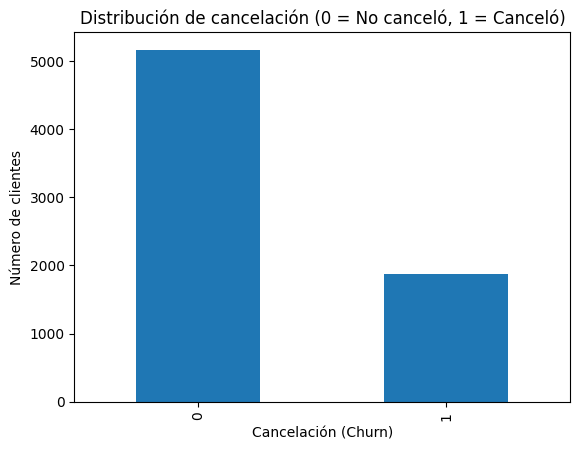

In [56]:
#Grafico simple
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")
plt.title("Distribución de cancelación (0 = No canceló, 1 = Canceló)")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Número de clientes")
plt.show()

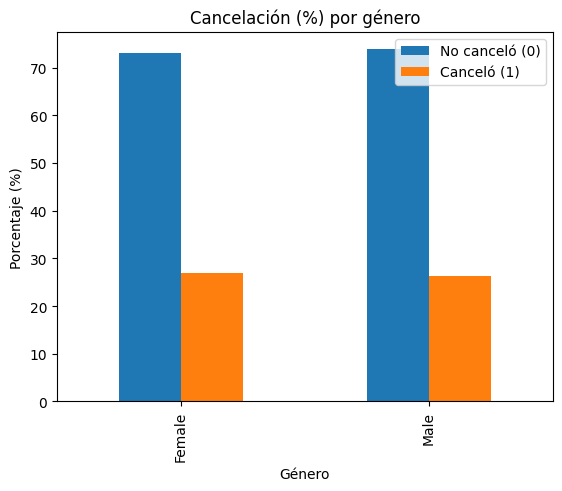

In [57]:
#Cancelación por género
#Comparo el % de cancelación entre grupos (género, contrato, internet, pago).
tabla = pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100
tabla.plot(kind="bar")
plt.title("Cancelación (%) por género")
plt.xlabel("Género")
plt.ylabel("Porcentaje (%)")
plt.legend(["No canceló (0)", "Canceló (1)"])
plt.show()

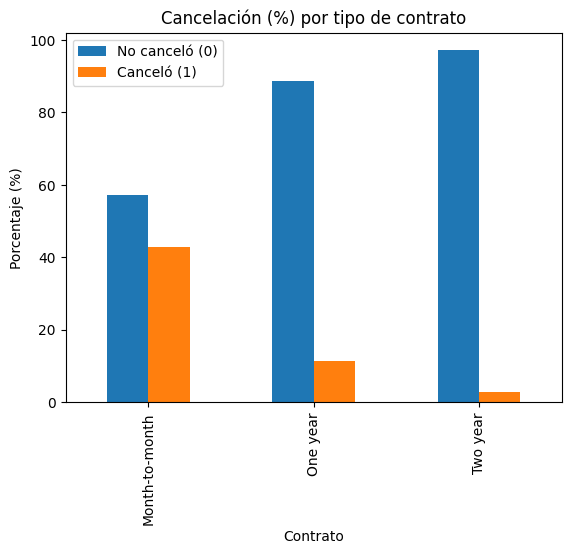

In [58]:
#Cancelación por tipo de contrato
tabla = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
tabla.plot(kind="bar")
plt.title("Cancelación (%) por tipo de contrato")
plt.xlabel("Contrato")
plt.ylabel("Porcentaje (%)")
plt.legend(["No canceló (0)", "Canceló (1)"])
plt.show()

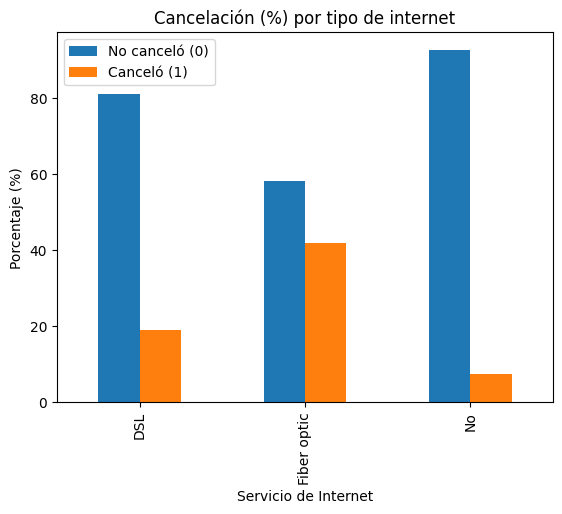

In [59]:
#Cancelación por tipo de internet
tabla = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
tabla.plot(kind="bar")
plt.title("Cancelación (%) por tipo de internet")
plt.xlabel("Servicio de Internet")
plt.ylabel("Porcentaje (%)")
plt.legend(["No canceló (0)", "Canceló (1)"])
plt.show()

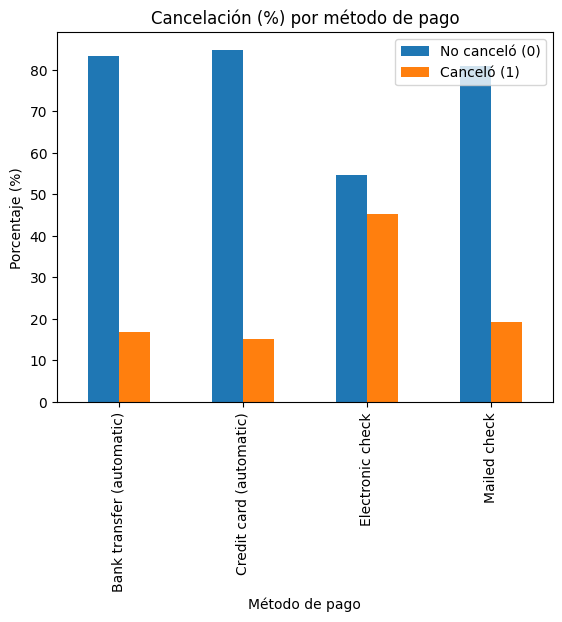

In [60]:
#Cancelación por metodo de pago
tabla = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
tabla.plot(kind="bar")
plt.title("Cancelación (%) por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Porcentaje (%)")
plt.legend(["No canceló (0)", "Canceló (1)"])
plt.show()

In [61]:
#Comparo si los que cancelan tienen diferente tenure, cargos, etc.
df.groupby("Churn")[cols_num].agg(["mean", "median", "std"])

tenure                   Charges.Monthly                    \
            mean median        std            mean median        std   
Churn                                                                  
0      37.650010   38.0  24.076940       61.307408  64.45  31.094557   
1      17.979133   10.0  19.531123       74.441332  79.65  24.666053   

      Charges.Total                       Cuentas_Diarias                      
               mean   median          std            mean    median       std  
Churn                                                                          
0       2555.344141  1683.60  2329.456984        2.043580  2.148333  1.036485  
1       1531.796094   703.55  1890.822994        2.481378  2.655000  0.822202

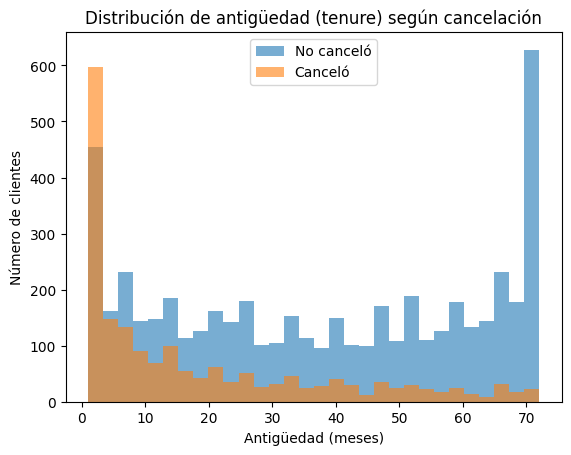

In [62]:
#Verificar si los clientes que cancelan tienen menos meses
df[df["Churn"]==0]["tenure"].plot(kind="hist", alpha=0.6, bins=30, label="No canceló")
df[df["Churn"]==1]["tenure"].plot(kind="hist", alpha=0.6, bins=30, label="Canceló")

plt.title("Distribución de antigüedad (tenure) según cancelación")
plt.xlabel("Antigüedad (meses)")
plt.ylabel("Número de clientes")
plt.legend()
plt.show()

#📄Informe final

##Introducción
En Telecom X se ha detectado una tasa alta de cancelación de clientes (churn). El objetivo de este trabajo fue entender qué características suelen estar presentes en los clientes que cancelan, usando datos demográficos, tipo de contrato, servicios contratados, método de pago y cargos.
La idea es que, con estos hallazgos, el equipo pueda enfocar mejor acciones de retención y, si se requiere, avanzar después hacia un modelo predictivo.

#Limpieza y tratamiento de datos

Antes de analizar, fue necesario preparar los datos para evitar conclusiones incorrectas.


* **Carga de datos:** se importaron los datos desde un archivo JSON publicado en línea y se convirtieron a un DataFrame de Pandas.
* **Normalización del JSON:** se aplanó la estructura del JSON para obtener columnas “planas” (tabla) que se pudieran analizar sin problemas.
* **Revisión inicial:** Se revisaron columnas, tipos de datos, valores faltantes, duplicados y valores vacíos (por ejemplo campos con espacios).

**Correcciones principales:**
* Se convirtió Charges.Total a valor numérico (porque venía como texto). Los valores no válidos quedaron como nulos.
* Se eliminaron registros con Churn vacío, ya que esa columna es la base del análisis.
* Se eliminaron los registros donde Charges.Total quedó nulo después de la conversión, para poder trabajar con esa variable sin errores.

**Estandarización recomendada (opcional):**


* Se renombraron columnas para que fueran más claras y consistentes con el diccionario de datos.
* Se transformaron variables “Yes/No” a formato 0/1 para facilitar cálculos y comparaciones.
* Se corrigieron valores como "No internet service" en servicios adicionales (por ejemplo seguridad o soporte), para evitar que se interpretaran como datos faltantes.

Variable adicional (opcional):

* Se creó Cuentas_Diarias como una estimación del cobro diario (Charges.Monthly / 30) para tener una referencia más detallada del gasto.

#Análisis exploratorio (EDA)

Con los datos ya limpios, se realizó un análisis para entender mejor el comportamiento general y las diferencias entre clientes que cancelan y los que no.

* **Estadística descriptiva:** se revisaron promedios, medianas y dispersión de variables numéricas como tenure, Charges.Monthly y Charges.Total.
* **Distribución de cancelación:** se calculó cuántos clientes cancelaron y qué porcentaje representan del total.
* **Comparaciones por grupos (con gráficas):** se revisó la cancelación según:
   *   género
   *   tipo de contrato
   *   tipo de servicio de internet
   *   método de pago



* **Comparación numérica:** se compararon valores promedio (y distribución) de tenure y cargos entre clientes que cancelan y los que permanecen, para identificar diferencias claras.

#Conclusiones e insights

A partir del análisis, se observan patrones útiles para entender la cancelación:

* La cancelación no ocurre “al azar”; tiende a concentrarse en ciertos perfiles de servicio y contrato.
* Variables como antigüedad del cliente (tenure), tipo de contrato, método de pago y nivel de servicios contratados suelen marcar diferencias entre quienes cancelan y quienes no.
* Los servicios adicionales (por ejemplo soporte técnico o seguridad) ayudan a segmentar mejor, porque reflejan qué tan “integrado” está el cliente al servicio.
* Tener los datos ordenados y consistentes deja lista la base para el siguiente paso: análisis más profundo o un modelo que estime riesgo de cancelación.



#Recomendaciones

Con base en los patrones revisados, estas acciones podrían ayudar a reducir la cancelación:

1. Enfocar retención en los segmentos con mayor riesgo (por ejemplo, ciertos tipos de contrato o perfiles de servicio).
2. Incentivar permanencia con beneficios para migrar a contratos de mayor duración (descuentos, upgrades temporales o promociones).
3. Mejorar la oferta de valor para clientes con pocos servicios contratados (paquetes más atractivos o beneficios por agregar servicios).
4. Revisar la experiencia de pago si se detecta que ciertos métodos se asocian a más cancelación (facilitar pagos, recordatorios, incentivos por domiciliación).
5. **Siguiente paso recomendado:** Usar esta base limpia para construir un modelo de churn y generar una lista de clientes “en riesgo”, para actuar antes de que cancelen.














